In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Path to your dataset folder in Google Drive
base_dir = '/content/drive/MyDrive/thesis-project-1'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
NUM_CLASSES = 3

In [16]:
# Load 70% as training
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load remaining 30%
val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 30% into validation and test
val_size = int(0.6667 * len(val_test_ds))  # about 20% of total
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

class_names = train_ds.class_names

print("Class names:", class_names)
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Testing batches:", len(test_ds))

Found 3015 files belonging to 3 classes.
Using 2111 files for training.
Found 3015 files belonging to 3 classes.
Using 904 files for validation.
Class names: ['BEVERAGE', 'SNACK', 'STAPLE']
Training batches: 66
Validation batches: 19
Testing batches: 10


In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

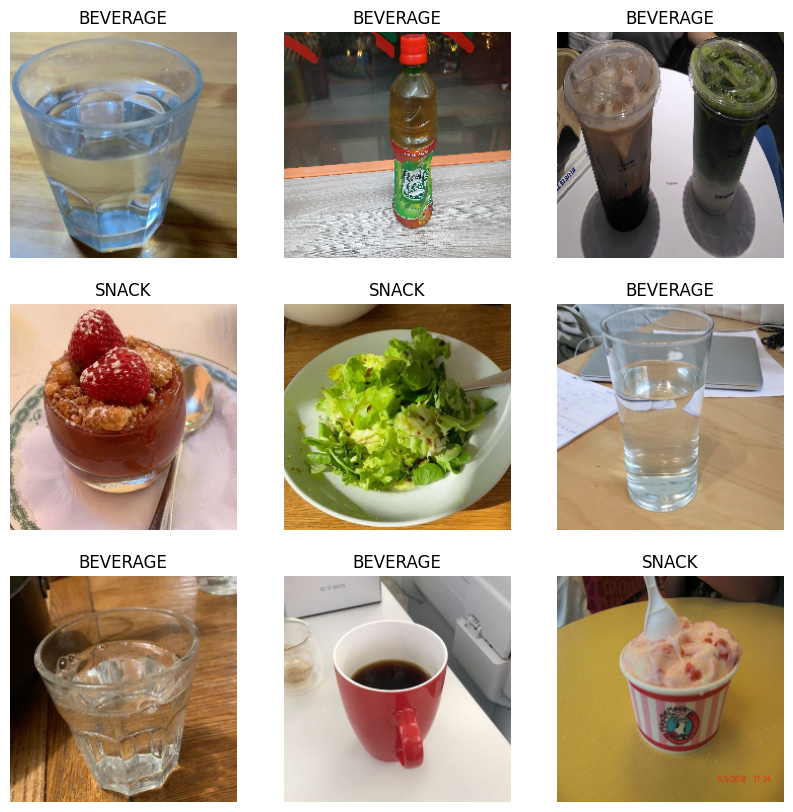

In [19]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # tell matplotlib values are [0,255]
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [20]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)          # converts [0,255] → [-1,1] correctly
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        'best_mobilenetv2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [22]:
initial_epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=callbacks
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7144 - loss: 0.6619
Epoch 1: val_accuracy improved from None to 0.88322, saving model to best_mobilenetv2.keras

Epoch 1: finished saving model to best_mobilenetv2.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 372s 6s/step - accuracy: 0.8304 - loss: 0.4160 - val_accuracy: 0.8832 - val_loss: 0.2512 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9119 - loss: 0.2209
Epoch 2: val_accuracy improved from 0.88322 to 0.90789, saving model to best_mobilenetv2.keras

Epoch 2: finished saving model to best_mobilenetv2.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.9152 - loss: 0.2250 - val_accuracy: 0.9079 - val_loss: 0.1950 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9295 - loss: 0.1775
Epoch 3: val_accuracy improved from 0.90789 to 0.91283, saving model to best_mobilenetv2.keras

Epoch 3: finished saving model to best_mobilenetv2.keras
66/66 ━━━━━━━━━

In [23]:
base_model.trainable = True

# Freeze most layers, unfreeze only later layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks
)

Epoch 14/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7784 - loss: 0.7000
Epoch 14: val_accuracy did not improve from 0.93257
66/66 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.8276 - loss: 0.4897 - val_accuracy: 0.9178 - val_loss: 0.2029 - learning_rate: 1.0000e-05
Epoch 15/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8847 - loss: 0.2737
Epoch 15: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 15: val_accuracy did not improve from 0.93257
66/66 ━━━━━━━━━━━━━━━━━━━━ 271s 3s/step - accuracy: 0.9010 - loss: 0.2325 - val_accuracy: 0.9178 - val_loss: 0.2150 - learning_rate: 1.0000e-05
Epoch 16/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9160 - loss: 0.2114
Epoch 16: val_accuracy did not improve from 0.93257
66/66 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9166 - loss: 0.2066 - val_accuracy: 0.9194 - val_loss: 0.2153 - learning_rate: 2.0000e-06
Epoch 17/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9150 - loss: 0.22

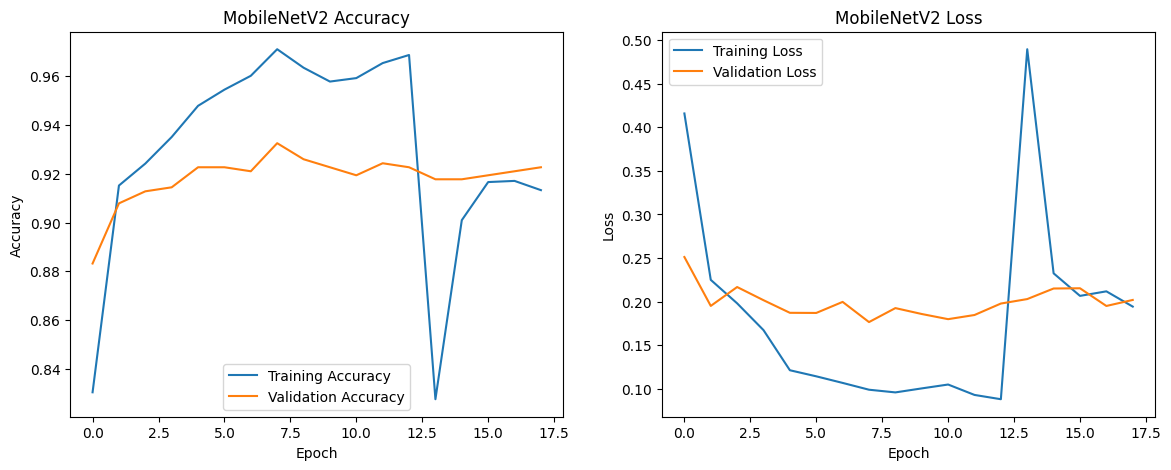

In [24]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [25]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8953 - loss: 0.2570
Test Loss: 0.2569904327392578
Test Accuracy: 0.8952702879905701


In [26]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    BEVERAGE       0.99      0.99      0.99        94
       SNACK       0.90      0.91      0.90        99
      STAPLE       0.92      0.91      0.92       103

    accuracy                           0.94       296
   macro avg       0.94      0.94      0.94       296
weighted avg       0.94      0.94      0.94       296



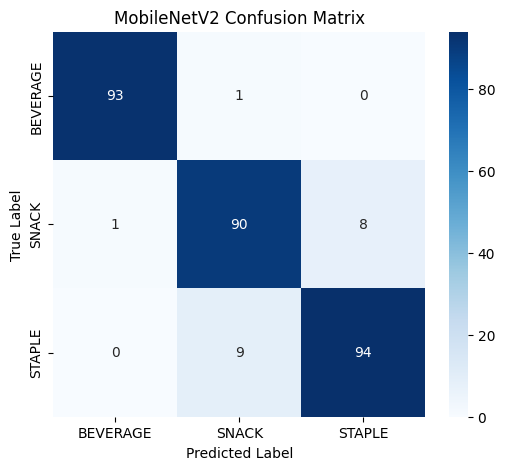

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

In [28]:
save_path = '/content/drive/MyDrive/mobilenetv2_meal_classifier.keras'
model.save(save_path)
print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/mobilenetv2_meal_classifier.keras


In [29]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_single_image(model, image_path, class_names):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    pred_index = np.argmax(prediction)
    pred_class = class_names[pred_index]
    confidence = float(np.max(prediction))

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_class} | Confidence: {confidence:.2%}")
    plt.show()

    return pred_class, confidence